<a href="https://colab.research.google.com/github/oxedanda/pml_final_project/blob/main/notebooks/01_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Machine Learning Final Project
# Predicting Annual Wine Production by Viticultural Region in Portugal

This notebook performs the first exploratory step of the project. It loads the cleaned wine production and vineyard area datasets, merges them by region and campaign year, and checks the resulting structure before further analysis.

In [14]:
from pathlib import Path

FIGURES_DIR = Path("outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Figures will be saved to:", FIGURES_DIR)

Figures will be saved to: outputs/figures


In [15]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# GitHub raw base URL
BASE_URL = "https://raw.githubusercontent.com/oxedanda/pml_final_project/main/data/processed"

PRODUCTION_FILE = f"{BASE_URL}/wine_production_by_region_clean.csv"
AREA_FILE = f"{BASE_URL}/vineyard_area_by_region_clean.csv"

# Load datasets directly from GitHub
production = pd.read_csv(PRODUCTION_FILE)
area = pd.read_csv(AREA_FILE)

# Quick check
print("Production shape:", production.shape)
print("Area shape:", area.shape)

display(production.head())
display(area.head())

Production shape: (238, 8)
Area shape: (288, 3)


,region,campaign_year,year_start,total_production_hl,dop_production_hl,igp_production_hl,year_variety_production_hl,non_certified_production_hl
0,Alentejo,2009/10,2009,810338,356783,449833,995,2728
1,Algarve,2009/10,2009,23650,4680,11797,0,7173
2,Açores,2009/10,2009,13754,2771,2832,6,8145
3,Bairrada,2009/10,2009,246705,69459,64138,1068,112041
4,Beira Interior,2009/10,2009,192084,50158,20570,14,121342


,region,year_start,vineyard_area_ha
0,Alentejo,1989,11510.0
1,Algarve,1989,2750.0
2,Açores,1989,2489.0
3,Lisboa,1989,46046.0
4,Madeira,1989,1803.0


In [16]:
# Merge production and vineyard area data
df = production.merge(
    area,
    on=["region", "year_start"],
    how="left"
)

# Show the result
print("Merged shape:", df.shape)
display(df.head(15))

Merged shape: (238, 9)


,region,campaign_year,year_start,total_production_hl,dop_production_hl,igp_production_hl,year_variety_production_hl,non_certified_production_hl,vineyard_area_ha
0,Alentejo,2009/10,2009,810338,356783,449833,995,2728,23490.00
1,Algarve,2009/10,2009,23650,4680,11797,0,7173,1983.00
2,Açores,2009/10,2009,13754,2771,2832,6,8145,1700.00
3,Bairrada,2009/10,2009,246705,69459,64138,1068,112041,NaN
4,Beira Interior,2009/10,2009,192084,50158,20570,14,121342,NaN
5,Douro,2009/10,2009,1351949,1186358,26986,0,138605,NaN
6,Dão,2009/10,2009,297483,221529,23022,0,52932,NaN
7,Lisboa,2009/10,2009,962323,55210,323594,0,583519,24799.00
8,Madeira,2009/10,2009,45449,39285,223,0,5940,1458.66
9,P. Setúbal,2009/10,2009,379371,108271,178274,507,92319,9210.00


In [17]:
# Check columns, missing values, and data types
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nBasic summary:")
display(df.describe(include="all"))

Columns:
['region', 'campaign_year', 'year_start', 'total_production_hl', 'dop_production_hl', 'igp_production_hl', 'year_variety_production_hl', 'non_certified_production_hl', 'vineyard_area_ha']

Missing values:


,missing_count
region,0
campaign_year,0
year_start,0
total_production_hl,0
dop_production_hl,0
igp_production_hl,0
year_variety_production_hl,0
non_certified_production_hl,0
vineyard_area_ha,38



Data types:


,dtype
region,object
campaign_year,object
year_start,int64
total_production_hl,int64
dop_production_hl,int64
igp_production_hl,int64
year_variety_production_hl,int64
non_certified_production_hl,int64
vineyard_area_ha,float64



Basic summary:


,region,campaign_year,year_start,total_production_hl,dop_production_hl,igp_production_hl,year_variety_production_hl,non_certified_production_hl,vineyard_area_ha
count,238,238,238.000000,2.380000e+02,2.380000e+02,2.380000e+02,238.000000,238.000000,200.000000
unique,14,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Alentejo,2009/10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,17,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2017.000000,4.658391e+05,2.452287e+05,1.401247e+05,2601.701681,78973.420168,13664.329950
std,NaN,NaN,4.909304,4.724759e+05,3.774793e+05,2.443040e+05,5425.161557,111748.747375,11460.963758
min,NaN,NaN,2009.000000,3.604000e+03,3.230000e+02,0.000000e+00,0.000000,236.000000,645.880000
25%,NaN,NaN,2013.000000,5.539325e+04,2.301050e+04,5.239750e+03,0.000000,7694.000000,1985.497500
50%,NaN,NaN,2017.000000,2.566495e+05,6.777350e+04,2.399300e+04,181.000000,42812.000000,12798.765000
75%,NaN,NaN,2021.000000,8.258348e+05,2.268278e+05,1.904995e+05,2654.750000,94333.250000,21434.167500


In [18]:
# Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Quick overview of the merged dataset
print("Merged dataset shape:", df.shape)
display(df.head())
display(df.describe(include="all"))

Merged dataset shape: (238, 9)


,region,campaign_year,year_start,total_production_hl,dop_production_hl,igp_production_hl,year_variety_production_hl,non_certified_production_hl,vineyard_area_ha
0,Alentejo,2009/10,2009,810338,356783,449833,995,2728,23490.0
1,Algarve,2009/10,2009,23650,4680,11797,0,7173,1983.0
2,Açores,2009/10,2009,13754,2771,2832,6,8145,1700.0
3,Bairrada,2009/10,2009,246705,69459,64138,1068,112041,NaN
4,Beira Interior,2009/10,2009,192084,50158,20570,14,121342,NaN


,region,campaign_year,year_start,total_production_hl,dop_production_hl,igp_production_hl,year_variety_production_hl,non_certified_production_hl,vineyard_area_ha
count,238,238,238.000000,2.380000e+02,2.380000e+02,2.380000e+02,238.000000,238.000000,200.000000
unique,14,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Alentejo,2009/10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,17,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2017.000000,4.658391e+05,2.452287e+05,1.401247e+05,2601.701681,78973.420168,13664.329950
std,NaN,NaN,4.909304,4.724759e+05,3.774793e+05,2.443040e+05,5425.161557,111748.747375,11460.963758
min,NaN,NaN,2009.000000,3.604000e+03,3.230000e+02,0.000000e+00,0.000000,236.000000,645.880000
25%,NaN,NaN,2013.000000,5.539325e+04,2.301050e+04,5.239750e+03,0.000000,7694.000000,1985.497500
50%,NaN,NaN,2017.000000,2.566495e+05,6.777350e+04,2.399300e+04,181.000000,42812.000000,12798.765000
75%,NaN,NaN,2021.000000,8.258348e+05,2.268278e+05,1.904995e+05,2654.750000,94333.250000,21434.167500


,missing_count
vineyard_area_ha,38
region,0
campaign_year,0
total_production_hl,0
year_start,0
dop_production_hl,0
igp_production_hl,0
year_variety_production_hl,0
non_certified_production_hl,0


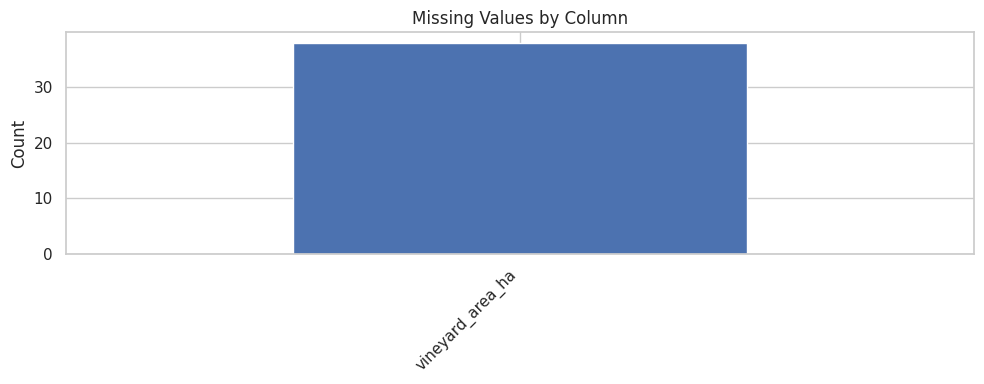

In [19]:
# Missing values summary
missing_counts = df.isna().sum().sort_values(ascending=False)

display(missing_counts.to_frame("missing_count"))

plt.figure(figsize=(10, 4))
missing_counts[missing_counts > 0].plot(kind="bar")
plt.title("Missing Values by Column")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "missing_values_by_column.png", dpi=300, bbox_inches="tight")
plt.show()

,total_production_hl
region,
Douro,24613688
Lisboa,19154503
Alentejo,18365309
Verdes,14577117
Tejo,10393384
P. Setúbal,7988440
Dão,4640695
Bairrada,3801543
Beira Interior,3662453


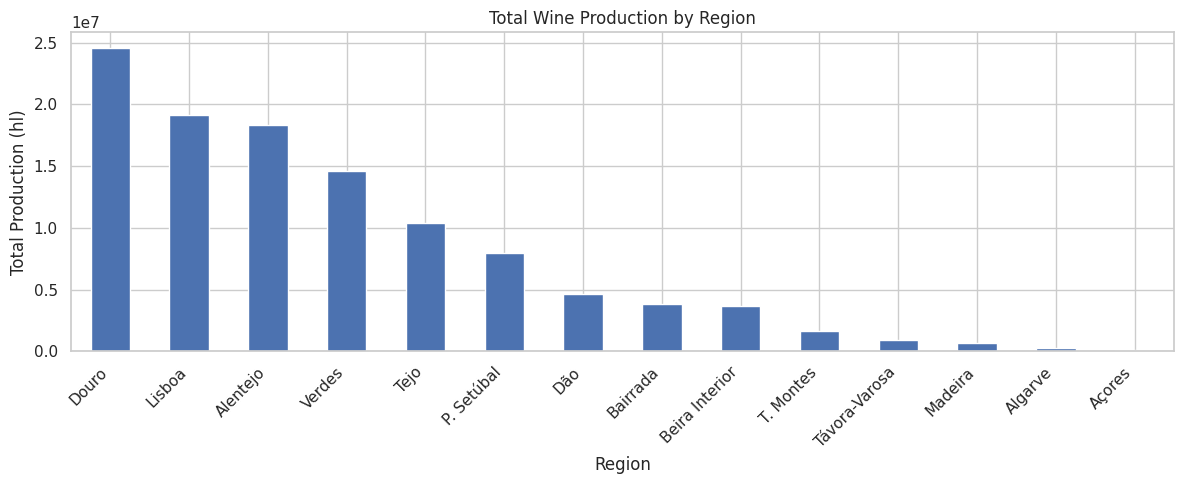

In [20]:
# Total wine production by region
region_production = (
    df.groupby("region")["total_production_hl"]
    .sum()
    .sort_values(ascending=False)
)

display(region_production.to_frame("total_production_hl"))

plt.figure(figsize=(12, 5))
region_production.plot(kind="bar")
plt.title("Total Wine Production by Region")
plt.ylabel("Total Production (hl)")
plt.xlabel("Region")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "total_wine_production_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

,total_production_hl
year_start,
2009,5893512
2010,7147929
2011,5622362
2012,6327107
2013,6231347
2014,6205757
2015,7047807
2016,6021969
2017,6736771


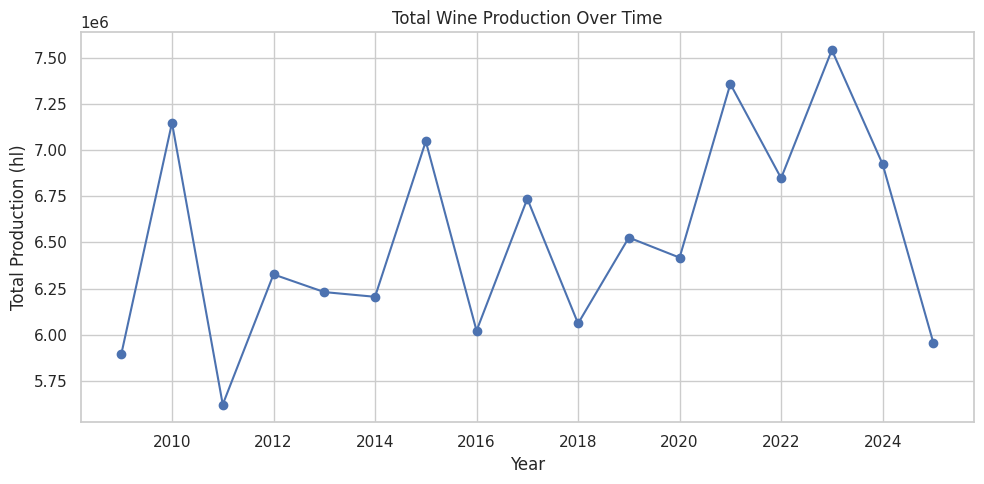

In [21]:
# Total production by year
year_production = (
    df.groupby("year_start")["total_production_hl"]
    .sum()
    .sort_index()
)

display(year_production.to_frame("total_production_hl"))

plt.figure(figsize=(10, 5))
plt.plot(year_production.index, year_production.values, marker="o")
plt.title("Total Wine Production Over Time")
plt.ylabel("Total Production (hl)")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "total_wine_production_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

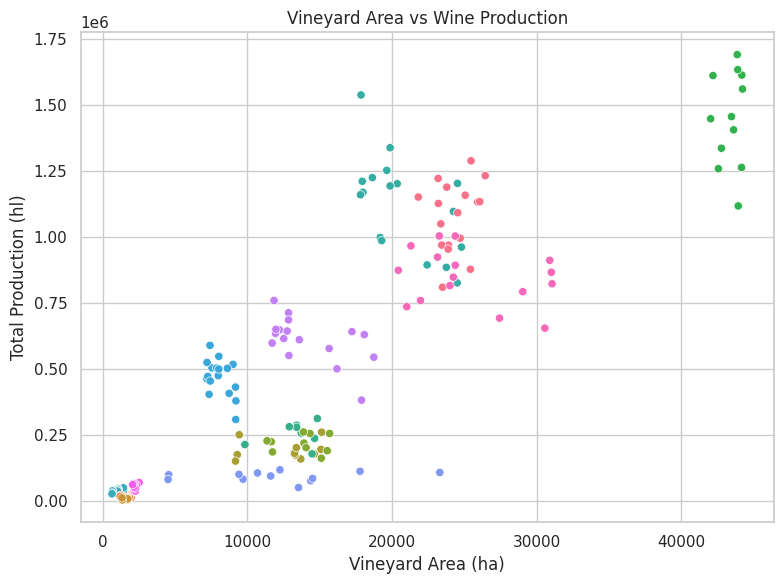

In [22]:
# Relationship between vineyard area and total production
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="vineyard_area_ha",
    y="total_production_hl",
    hue="region",
    legend=False
)
plt.title("Vineyard Area vs Wine Production")
plt.xlabel("Vineyard Area (ha)")
plt.ylabel("Total Production (hl)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "vineyard_area_vs_wine_production.png", dpi=300, bbox_inches="tight")
plt.show()

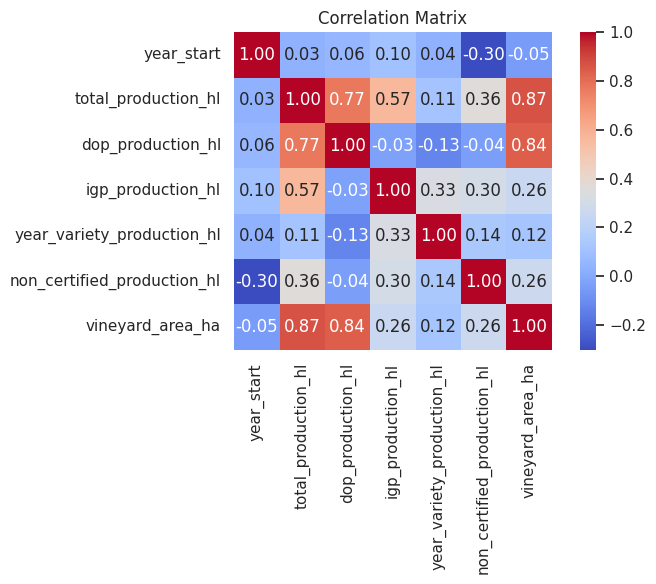

In [23]:
# Correlation among numeric variables
numeric_cols = df.select_dtypes(include=["number"]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

Key Observations

The merged dataset contains 238 observations, combining wine production and vineyard area by region and campaign year.

Vineyard area is missing for 38 region-year combinations, likely reflecting incomplete historical coverage for certain regions rather than random missingness. This should be considered when using this variable in modeling.

Douro, Lisboa, and Alentejo are the dominant contributors to total wine production in the dataset.

Wine production shows clear inter-annual variability across the observed period.

There is a positive association between vineyard area and production, although the relationship is not strictly linear and is influenced by regional heterogeneity.

The correlation matrix is useful for exploratory analysis, but it does not imply causal relationships.